In [1]:
#Importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('framingham.csv')

In [3]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [4]:
df.dtypes

male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

In [5]:
#Converting boolean categories as a category
cat_cols = ['education','currentSmoker','BPMeds','prevalentStroke','prevalentHyp','diabetes','TenYearCHD']
df[cat_cols] = df[cat_cols].astype('category')

In [6]:
#Missing values
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [7]:
# Handling Missing values
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
cat_cols = df.select_dtypes(include='category').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [8]:
df.isna().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

In [9]:
df.shape

(4240, 16)

### Feature Engineering

In [10]:
#Converting male to sex
df['sex'] = df['male'].replace({0:'female',1:'male'})

In [11]:
#Classifying age to child or adult
def classify_age(age):
    if age<18:
        return 'Child'
    else:
        return 'Adult'

df['age_cat'] = df['age'].apply(classify_age)

In [12]:
#Classifying smokers categories
def classify_smoking(cigs):
    if cigs == 0:
        return 'Non-Smoker'
    elif cigs <= 10:
        return 'Light'
    elif cigs <= 20:
        return 'Moderate'
    else:
        return 'Heavy'

df['smoking_category'] = df['cigsPerDay'].apply(classify_smoking)

In [13]:
#Classifying blood pressure categories
def classify_bp(row):
    sys = row['sysBP']    
    dia = row['diaBP'] 
    if pd.isna(sys) and pd.isna(dia):
        return 'Unknown'
    if (sys < 90) or (dia < 60):
        return 'Hypotensive'
    if (sys >= 130) or (dia >= 80):
        return 'Hypertensive'
    return 'Normal'

df['bp_category'] = df.apply(classify_bp, axis=1)

In [14]:
#Classifying glucose level categories
def classify_glucose(glucose):
    if pd.isna(glucose):
        return 'Unknown'
    elif glucose < 70:
        return 'Hypoglycemia'
    elif glucose <= 139:
        return 'Normal'
    elif glucose <= 199:
        return 'Prediabetes'
    else:
        return 'Diabetes'

df['glucose_category'] = df['glucose'].apply(classify_glucose)

In [15]:
#Dropping redundant columns
df = df.drop(columns=['currentSmoker','male'])

### EDA

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df.describe()

,age,cigsPerDay,totChol,sysBP,diaBP,BMI,heartRate,glucose
count,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000
mean,49.580189,8.944340,236.667689,132.354599,82.897759,25.799005,75.878774,81.600943
std,8.572942,11.904777,44.328480,22.033300,11.910394,4.070775,12.023937,22.860340
min,32.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000
25%,42.000000,0.000000,206.000000,117.000000,75.000000,23.077500,68.000000,72.000000
50%,49.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000
75%,56.000000,20.000000,262.000000,144.000000,90.000000,28.032500,83.000000,85.000000
max,70.000000,70.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000


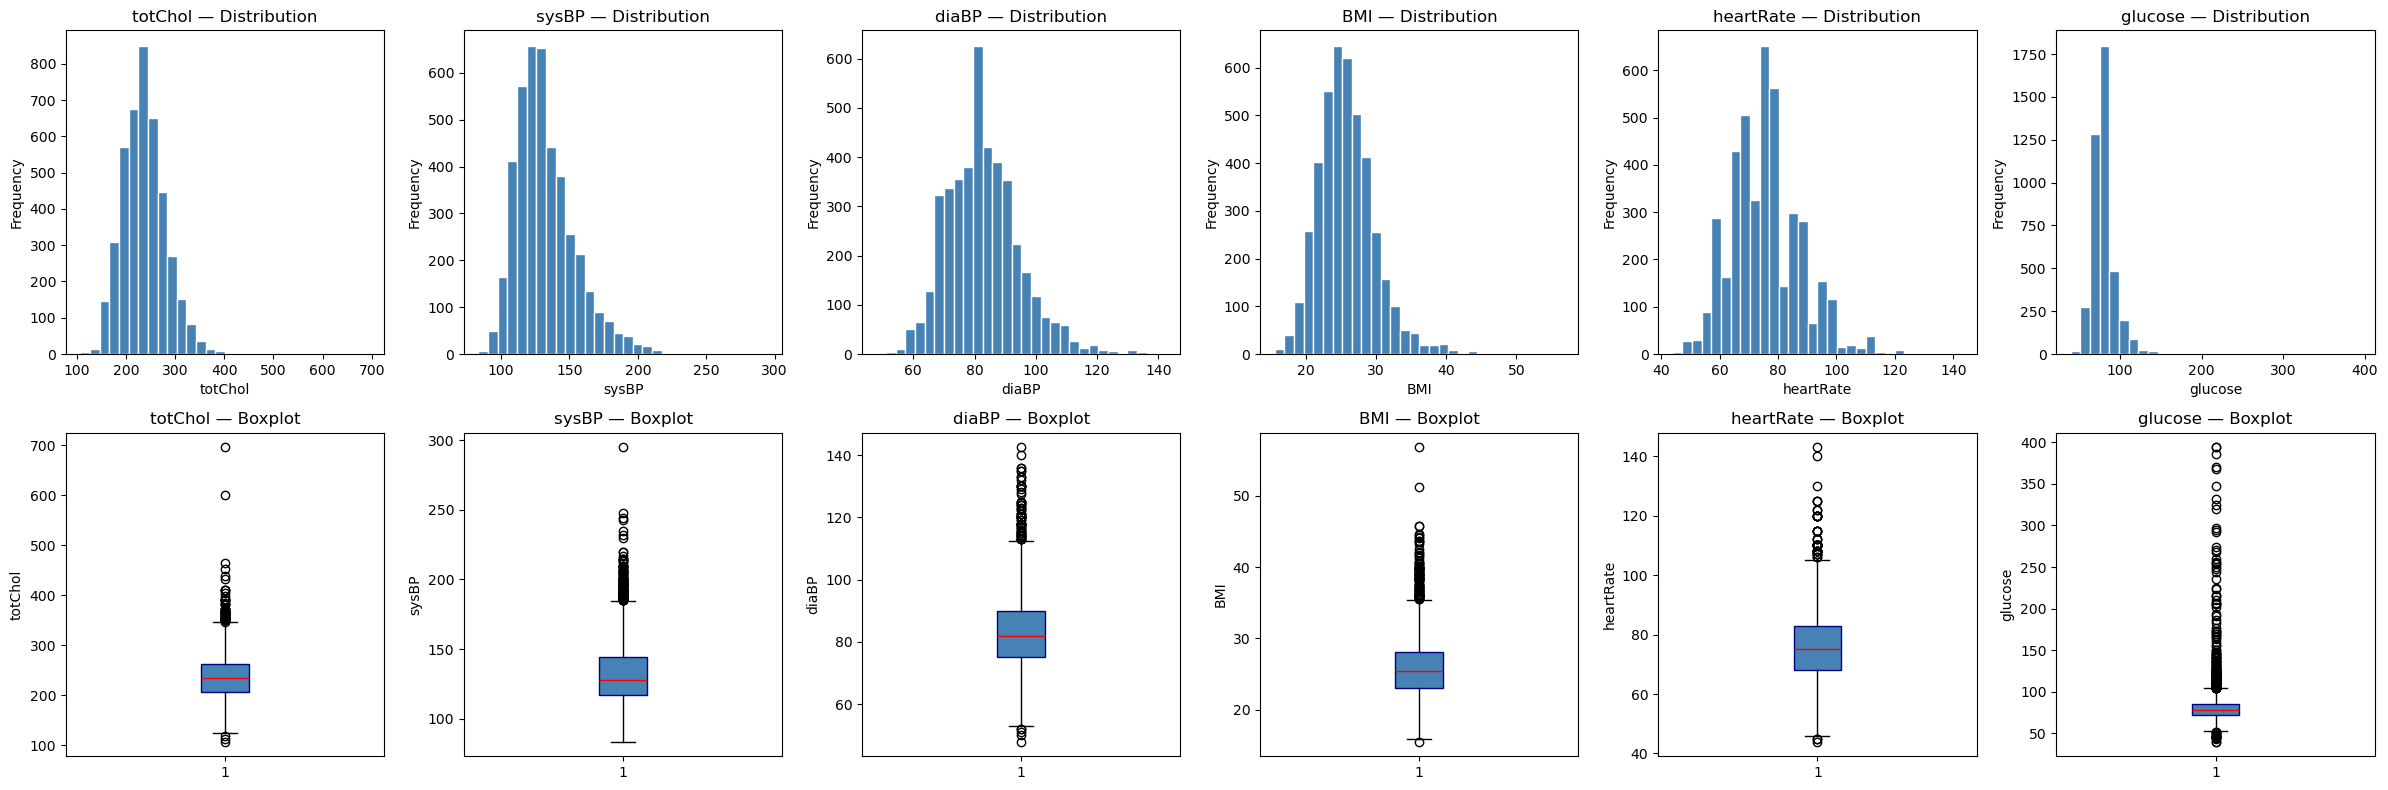

In [18]:
#Distribution of numerical columns
float_cols = ['totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

fig, axes = plt.subplots(2, 6, figsize=(24, 8))

for i, col in enumerate(float_cols):
    axes[0, i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'{col} — Distribution')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frequency')
    axes[1, i].boxplot(df[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor='steelblue', color='navy'),
                       medianprops=dict(color='red'))
    axes[1, i].set_title(f'{col} — Boxplot')
    axes[1, i].set_ylabel(col)
plt.tight_layout()
plt.savefig('outlier_check.png')
plt.show()

Text(0.5, 1.0, 'Correlation of Numerical Columns')

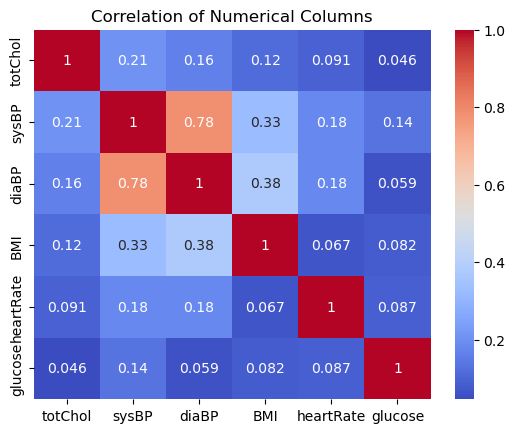

In [19]:
#Heatmap of correlation of numerical columns
sns.heatmap(df[float_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation of Numerical Columns')

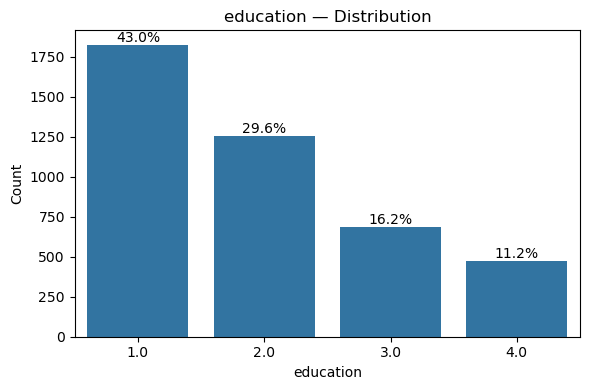

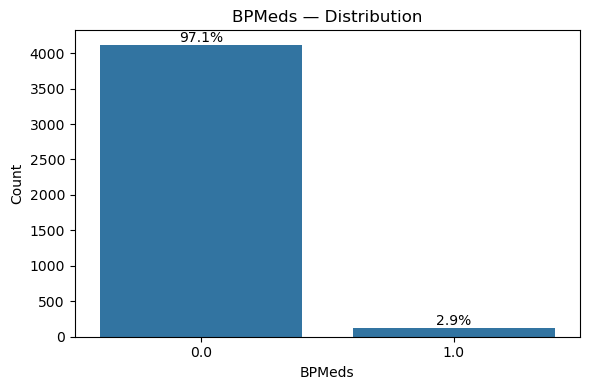

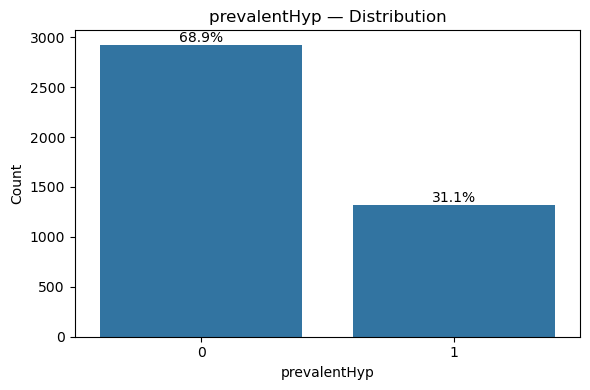

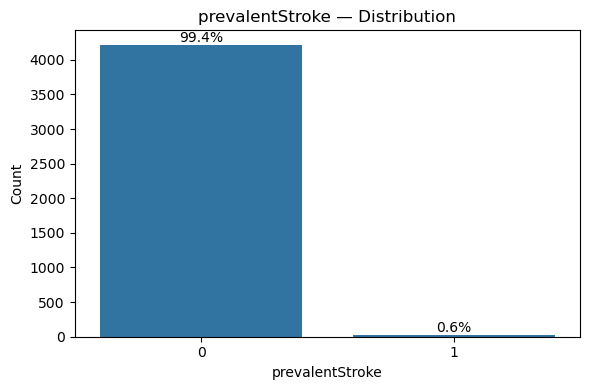

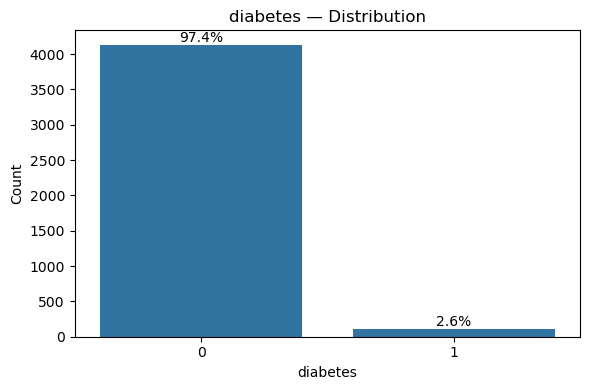

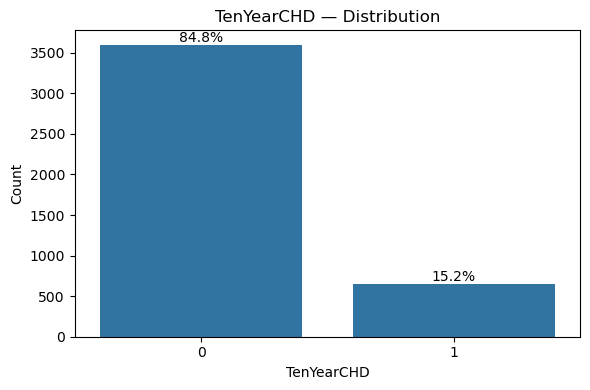

In [20]:
#Distribution of categorical columns
cat_cols = ['education','BPMeds', 'prevalentHyp', 'prevalentStroke', 'diabetes','TenYearCHD']
for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col)
    plt.title(f'{col} — Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')

    total = len(df[col].dropna())
    for p in plt.gca().patches:
        pct = f'{100 * p.get_height() / total:.1f}%'
        plt.gca().annotate(pct,
                           (p.get_x() + p.get_width() / 2, p.get_height()),
                           ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.savefig(f'{col}_countplot.png', )
    plt.show()

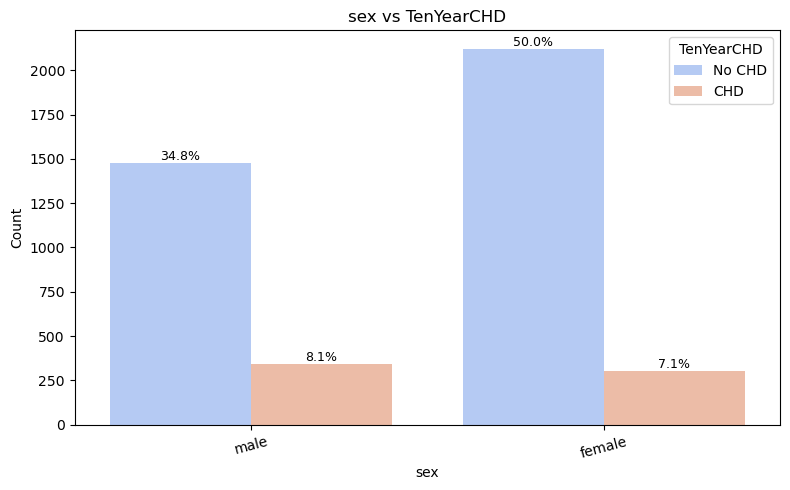

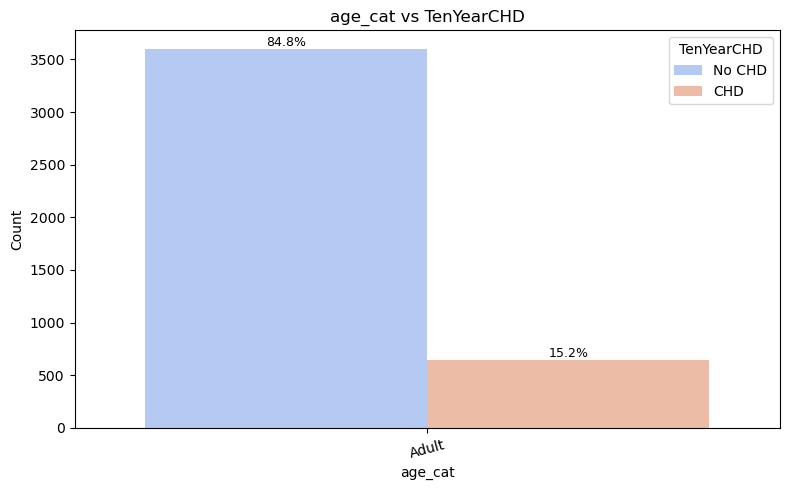

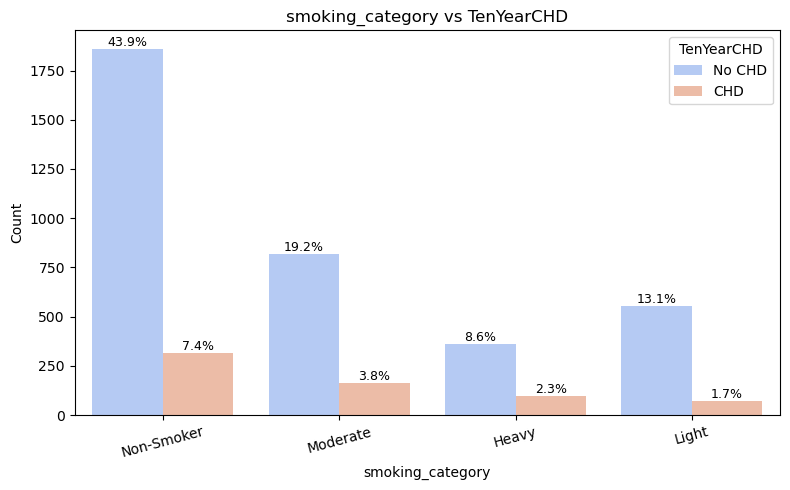

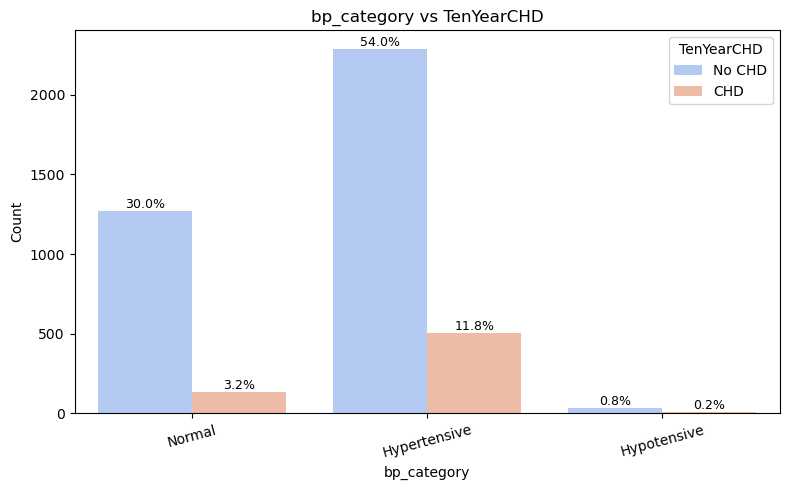

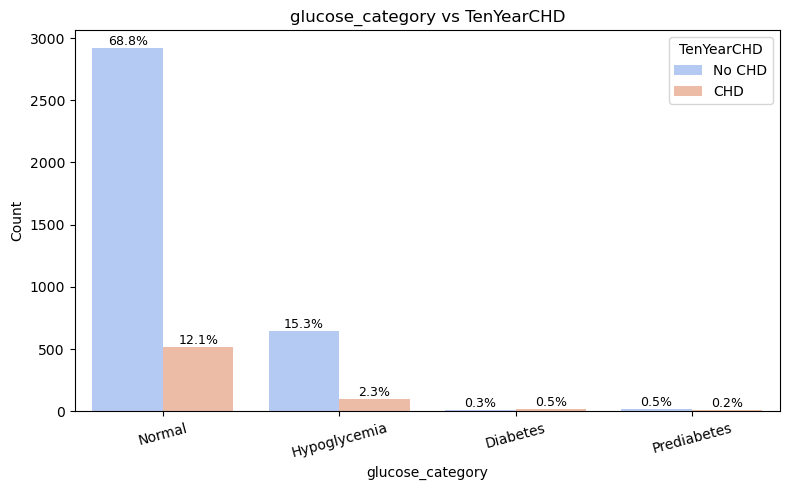

In [21]:
#Relationship between features and target column
features = ['sex', 'age_cat', 'smoking_category', 'bp_category', 'glucose_category']

for col in features:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=col, hue='TenYearCHD', palette='coolwarm')
    plt.title(f'{col} vs TenYearCHD')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='TenYearCHD', labels=['No CHD', 'CHD'])
    plt.xticks(rotation=15)

    # percentage labels
    total = len(df)
    for p in plt.gca().patches:
        height = p.get_height()
        if height > 0:
            pct = f'{100 * height / total:.1f}%'
            plt.gca().annotate(pct,
                               (p.get_x() + p.get_width() / 2, height),
                               ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'{col}_vs_TenYearCHD.png', dpi=150)
    plt.show()

### Outlier handling

In [22]:

out_cols = ['heartRate', 'totChol', 'glucose']

for col in out_cols:
    lower = df[col].quantile(0.05)
    upper = df[col].quantile(0.95)
    df[col] = df[col].clip(lower=lower, upper=upper)

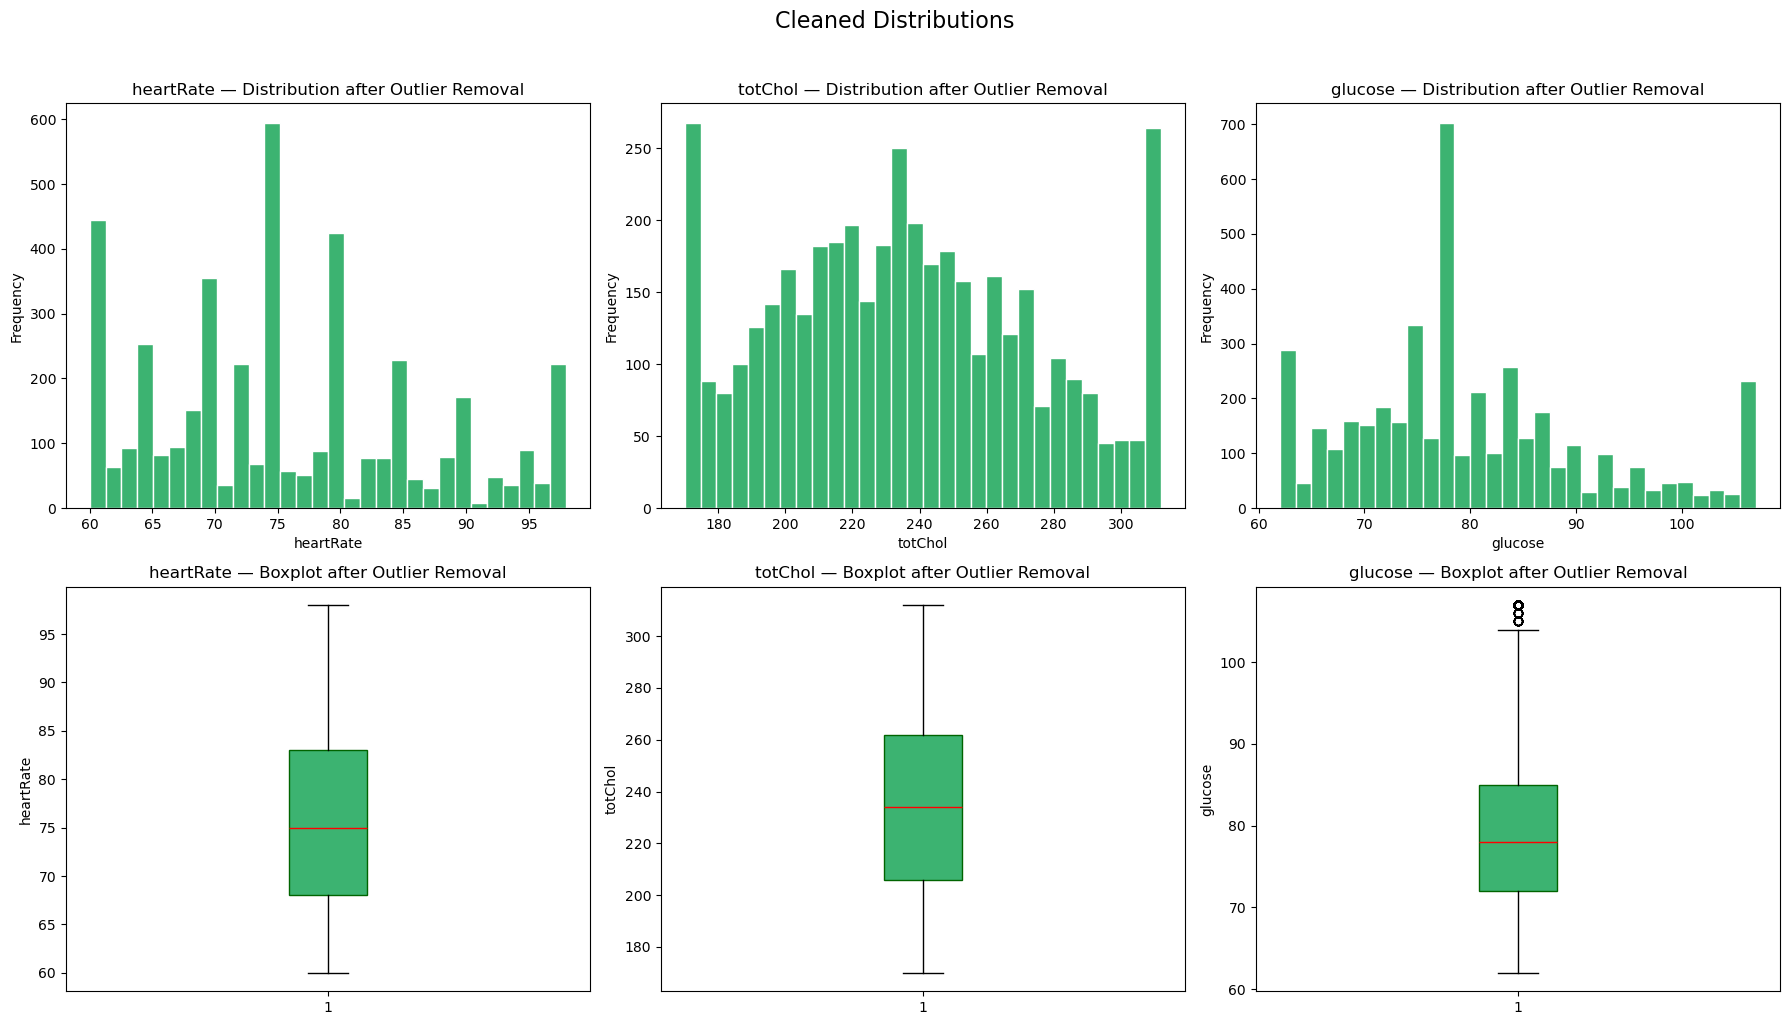

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

out_cols = ['heartRate', 'totChol', 'glucose']

for i, col in enumerate(out_cols):
    # Histogram — top row
    axes[0, i].hist(df[col].dropna(), bins=30, color='mediumseagreen', edgecolor='white')
    axes[0, i].set_title(f'{col} — Distribution after Outlier Removal')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frequency')

    # Boxplot — bottom row
    axes[1, i].boxplot(df[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor='mediumseagreen', color='darkgreen'),
                       medianprops=dict(color='red'))
    axes[1, i].set_title(f'{col} — Boxplot after Outlier Removal')
    axes[1, i].set_ylabel(col)

plt.suptitle('Cleaned Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('clean.png', dpi=150)
plt.show()